In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('files/net_users_num.csv')

print("First 5 rows of the data:")
print(df.head())

print("\nInformation about the DataFrame:")
print(df.info())

First 5 rows of the data:
       country 1990 1991 1992 1993 1994  1995  1996  1997  1998  ...   2010  \
0  Afghanistan    0    0    0    0    0     0   NaN   NaN   NaN  ...  1.17M   
1       Angola    0    0    0    0    0     0   112   844  2830  ...   654k   
2      Albania    0    0    0    0    0   348   998  1510  2020  ...  1.33M   
3      Andorra    0    0    0    0    0     0   983  1960  4420  ...  68.4k   
4          UAE    0    0    0    0    0  2490  9530   88k  194k  ...  5.81M   

    2011   2012   2013   2014   2015   2016   2017   2018   2019  
0  1.51M   1.7M   1.9M  2.34M  2.84M  3.96M   4.9M  5.02M  5.14M  
1   751k  1.63M  2.32M  5.77M  3.46M  3.75M  4.28M  4.42M  4.56M  
2  1.44M  1.59M  1.66M  1.74M  1.83M  1.92M  2.07M  2.07M  2.01M  
3  67.8k  71.2k  75.9k    76k  75.6k  75.7k  70.5k  70.5k  70.6k  
4  6.98M  7.77M  8.09M  8.33M  8.38M  8.48M     9M  9.48M  9.69M  

[5 rows x 31 columns]

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
Ra

In [3]:
def clean_and_convert(value):
    if pd.isna(value) or value == '':
        return 0
    s_value = str(value)
    if 'k' in s_value:
        return int(float(s_value.replace('k', '')) * 1000)
    elif 'M' in s_value:
        return int(float(s_value.replace('M', '')) * 1000000)
    else:
        return int(float(s_value))

df.rename(columns={'country': 'Country'}, inplace=True)

year_columns = [col for col in df.columns if col.isdigit()]

for col in year_columns:
    df[col] = df[col].apply(clean_and_convert)

print("First 5 rows of the data after cleaning and conversion:")
print(df.head())

print("\nInformation about the DataFrame after cleaning:")
print(df.info())

First 5 rows of the data after cleaning and conversion:
       Country  1990  1991  1992  1993  1994  1995  1996   1997    1998  ...  \
0  Afghanistan     0     0     0     0     0     0     0      0       0  ...   
1       Angola     0     0     0     0     0     0   112    844    2830  ...   
2      Albania     0     0     0     0     0   348   998   1510    2020  ...   
3      Andorra     0     0     0     0     0     0   983   1960    4420  ...   
4          UAE     0     0     0     0     0  2490  9530  88000  194000  ...   

      2010     2011     2012     2013     2014     2015     2016     2017  \
0  1170000  1510000  1700000  1900000  2340000  2840000  3960000  4900000   
1   654000   751000  1630000  2320000  5770000  3460000  3750000  4280000   
2  1330000  1440000  1590000  1660000  1740000  1830000  1920000  2069999   
3    68400    67800    71200    75900    76000    75600    75700    70500   
4  5810000  6980000  7770000  8090000  8330000  8380000  8480000  9000000   



C:\Users\lion\AppData\Local\Temp\ipykernel_14448\1831415352.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.2f}B'.format(x/1_000_000_000) for x in current_values])


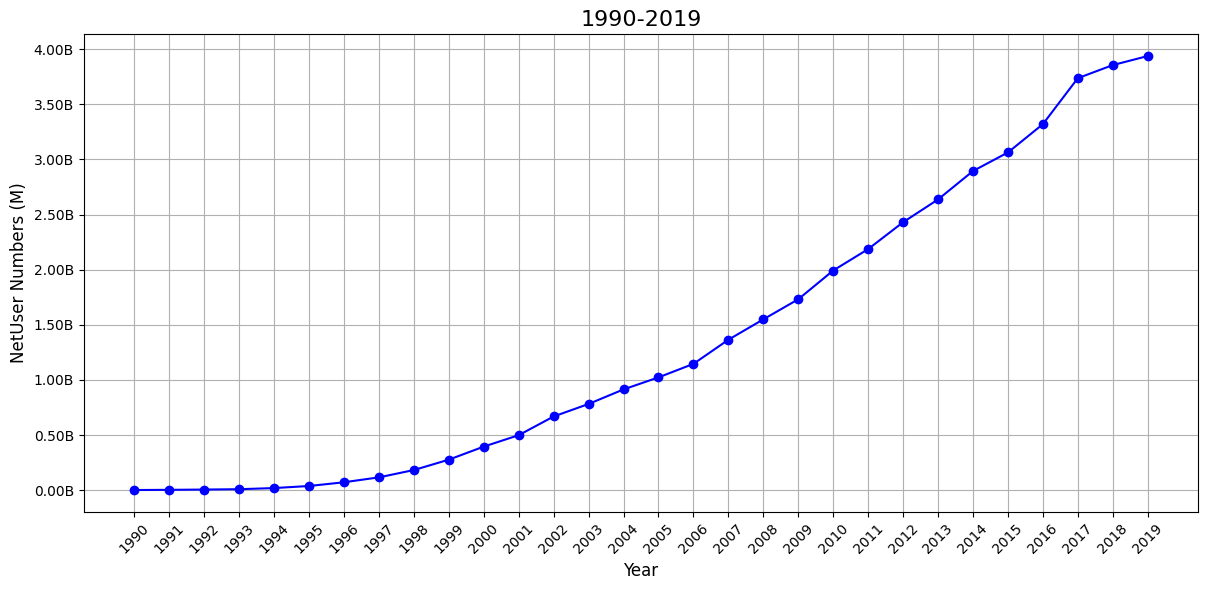

In [5]:
total_users_by_year = df[year_columns].sum()

plt.figure(figsize=(12, 6))
plt.plot(total_users_by_year.index, total_users_by_year.values, marker='o', linestyle='-', color='b')
plt.title('1990-2019', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('NetUser Numbers (M)', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.2f}B'.format(x/1_000_000_000) for x in current_values])

plt.savefig('global_internet_users_trend.png')

C:\Users\lion\AppData\Local\Temp\ipykernel_14448\498358771.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:,.1f}B'.format(x/1_000_000_000) for x in current_values])


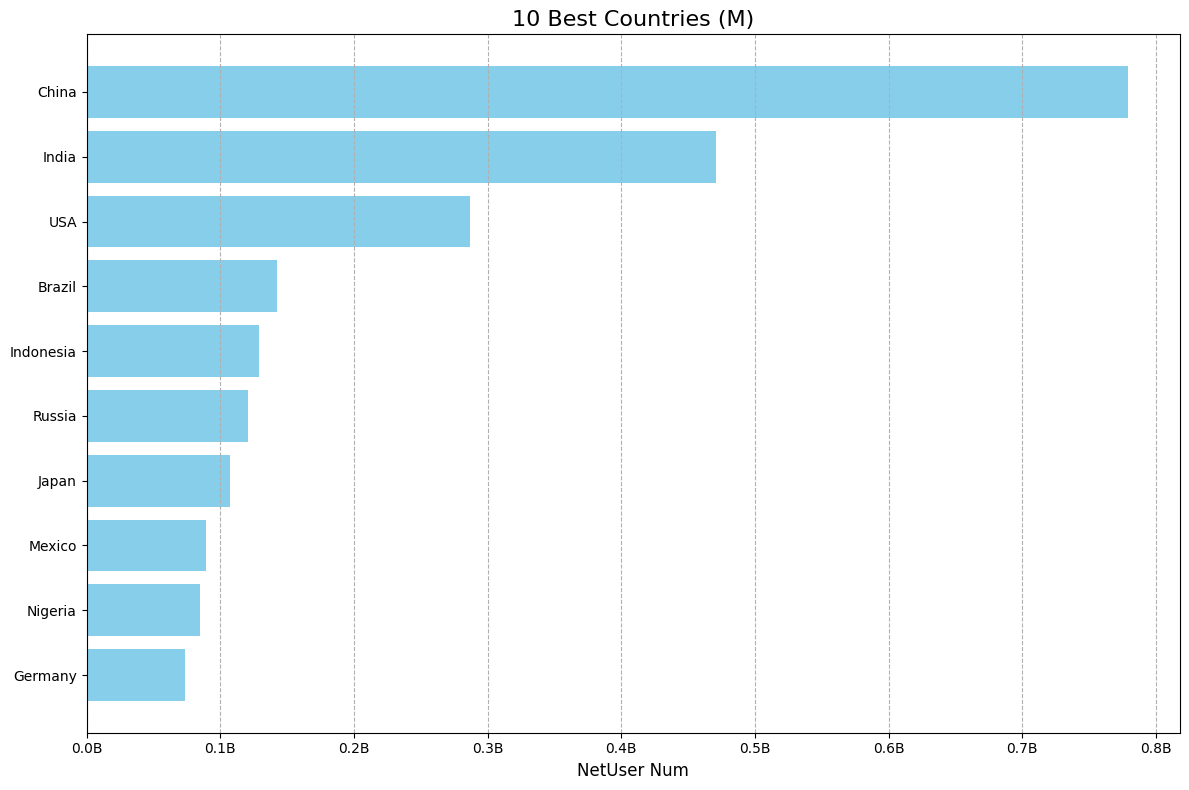

In [7]:
top_10_countries_2019 = df[['Country', '2019']].sort_values(by='2019', ascending=False).head(10)

plt.figure(figsize=(12, 8))
plt.barh(top_10_countries_2019['Country'], top_10_countries_2019['2019'], color='skyblue')
plt.xlabel('NetUser Num', fontsize=12)
plt.title('10 Best Countries (M)', fontsize=16)
plt.grid(axis='x', linestyle='--')
plt.gca().invert_yaxis()
plt.tight_layout()
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.1f}B'.format(x/1_000_000_000) for x in current_values])

plt.savefig('top_10_countries_2019.png')

In [8]:
df['user_increase_1999_2019'] = df['2019'] - df['1999']

top_10_growth = df[['Country', 'user_increase_1999_2019']].sort_values(by='user_increase_1999_2019', ascending=False).head(10)

print("Top 10 countries with the highest increase in internet users from 1999 to 2019:")
print(top_10_growth)

Top 10 countries with the highest increase in internet users from 1999 to 2019:
       Country  user_increase_1999_2019
32       China                769920000
78       India                468160000
185        USA                187100000
23      Brazil                138490000
77   Indonesia                128073000
148     Russia                119500000
112     Mexico                 87590000
127    Nigeria                 84351100
87       Japan                 79800000
189    Vietnam                 66198000


In [10]:
zero_users_2019 = df[df['2019'] == 0]

print("Countries with 0 internet users in 2019:")
print(zero_users_2019['Country'])

Countries with 0 internet users in 2019:
139          Palau
142    North Korea
Name: Country, dtype: object


In [11]:
df['growth_rate_2009_2019'] = ((df['2019'] - df['2009']) / (df['2009'] + 1)) * 100

top_10_growth_rate = df[['Country', 'growth_rate_2009_2019']].sort_values(by='growth_rate_2009_2019', ascending=False).head(10)

print("Top 10 countries with the highest percentage growth in internet users (2009-2019):")
print(top_10_growth_rate)

Top 10 countries with the highest percentage growth in internet users (2009-2019):
              Country  growth_rate_2009_2019
160       South Sudan           8.820000e+07
132             Nauru           6.140000e+05
117           Myanmar           1.485482e+04
91           Cambodia           8.721838e+03
81               Iraq           6.219198e+03
55           Ethiopia           4.443469e+03
155      Sierra Leone           4.212625e+03
64             Guinea           2.354617e+03
33      Cote d'Ivoire           2.236653e+03
35   Congo, Dem. Rep.           2.037137e+03


In [21]:
print("Unique country names containing 'Iran':", df[df['Country'].str.contains('iran', case=False, na=False)]['Country'].unique())
print("Unique country names containing 'China':", df[df['Country'].str.contains('China', case=True, na=True)]['Country'].unique())
print("Unique country names containing 'USA':", df[df['Country'].str.contains('usa', case=False, na=False)]['Country'].unique())

Unique country names containing 'Iran': ['Iran']
Unique country names containing 'China': ['China' 'Hong Kong, China']
Unique country names containing 'USA': ['USA']


C:\Users\lion\AppData\Local\Temp\ipykernel_14448\1181628070.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.1f}M'.format(x/1_000_000) for x in current_values])


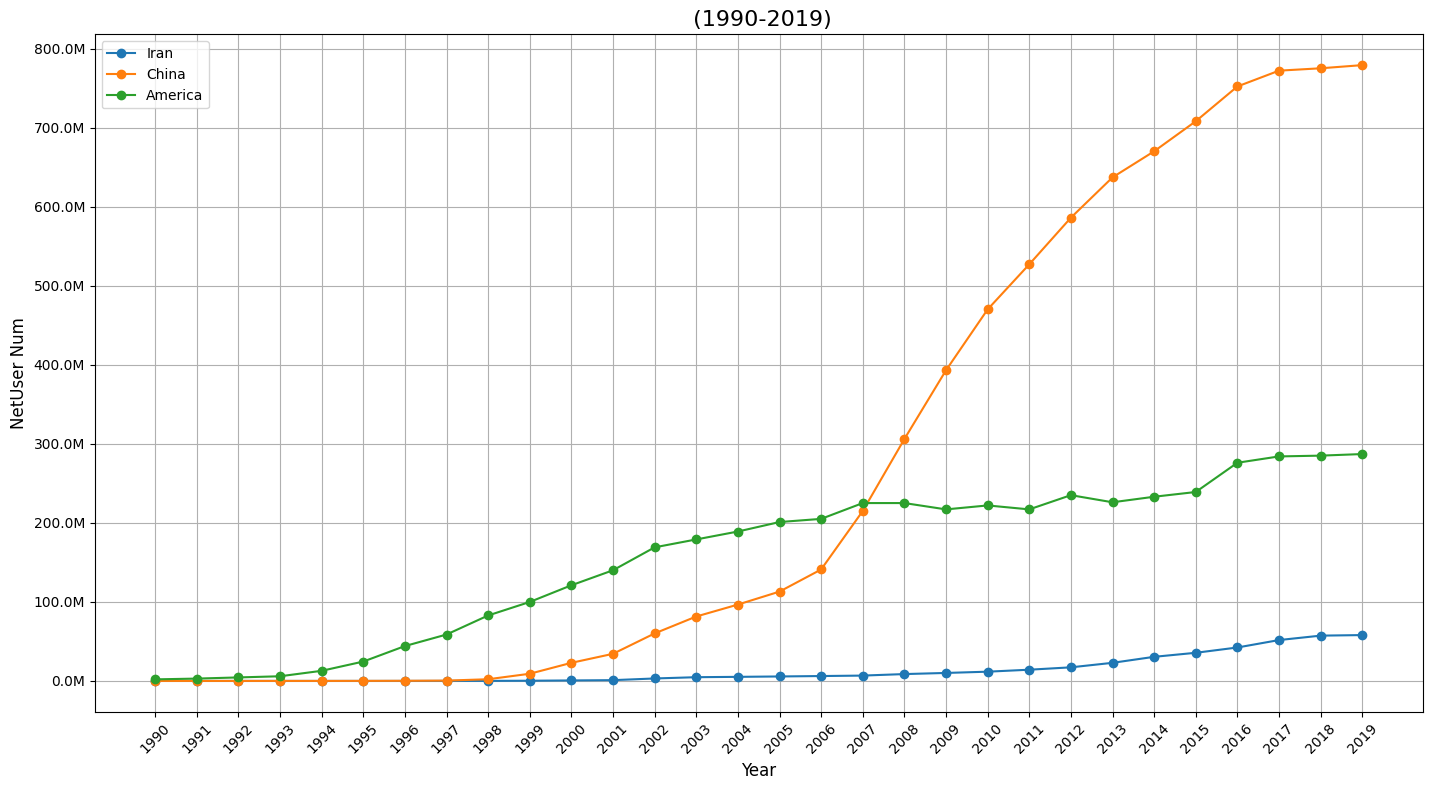

In [15]:
iran_data = df[df['Country'] == 'Iran'].iloc[0]
china_data = df[df['Country'] == 'China'].iloc[0]
usa_data = df[df['Country'] == 'USA'].iloc[0]

years = [col for col in df.columns if col.isdigit()]

plot_df = pd.DataFrame({
    'Year': years,
    'Iran': iran_data[years].values,
    'China': china_data[years].values,
    'America': usa_data[years].values
})

plt.figure(figsize=(14, 8))
plt.plot(plot_df['Year'], plot_df['Iran'], label='Iran', marker='o')
plt.plot(plot_df['Year'], plot_df['China'], label='China', marker='o')
plt.plot(plot_df['Year'], plot_df['America'], label='America', marker='o')

plt.title(' (1990-2019)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('NetUser Num', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.1f}M'.format(x/1_000_000) for x in current_values])

plt.savefig('iran_china_usa_comparison.png')

C:\Users\lion\AppData\Local\Temp\ipykernel_14448\4157317859.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.1f}M'.format(x/1_000_000) for x in current_values])


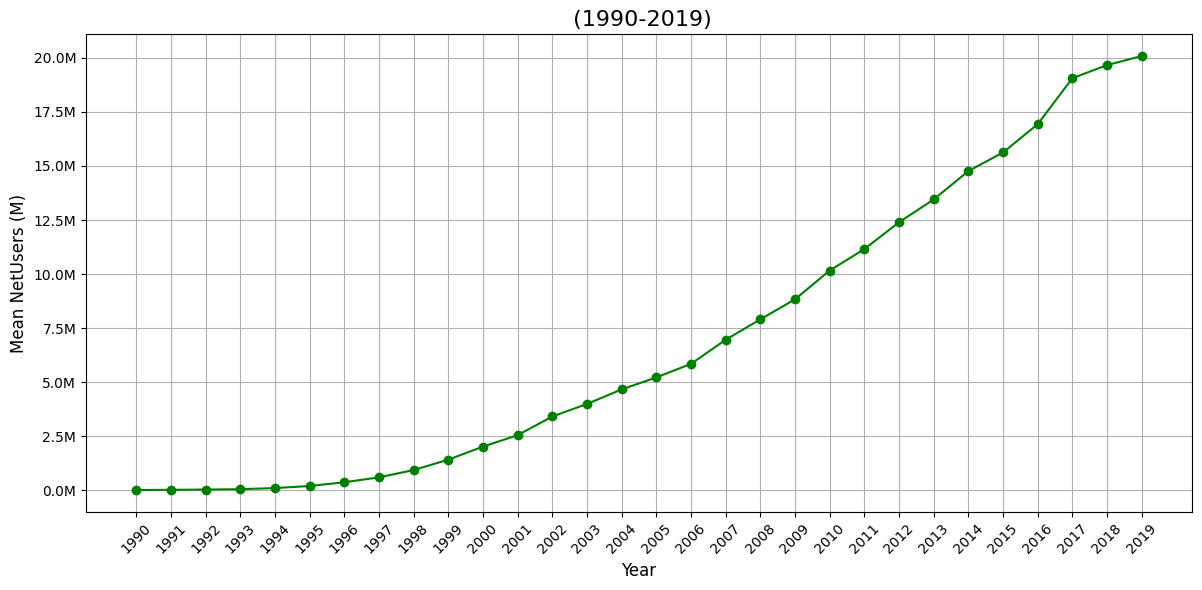

In [17]:
average_users_by_year = df[years].mean()

plt.figure(figsize=(12, 6))
plt.plot(average_users_by_year.index, average_users_by_year.values, marker='o', linestyle='-', color='g')
plt.title(' (1990-2019)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean NetUsers (M)', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.1f}M'.format(x/1_000_000) for x in current_values])

plt.savefig('average_internet_users_trend.png')